# Simulating Short Rate and Zero Coupon Bond Yields

In [15]:
import os
from codelib.file_management.dynamic_file_pathing import get_root
from typing import Union
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from codelib.Johan.visualization.base import fan_chart
from codelib.Models.vasicek_model import VasicekModel

## Setting up

In [16]:
root = get_root()
data_folder = os.path.join(root, "GBI Optimisation", "Data")
output_folder = os.path.join(root, "Simulation", "Bonds")

np.random.seed(222)
short_rate = os.path.join(root, "Miscellaneous", "Archive", "Data", "short_rate.xlsx")


## Initialise parameters for simulation

In [40]:
ppa = 252

vas = VasicekModel(short_rate,ppa)
initial_rate=vas.rates.iloc[-1]
kappa, theta, beta = vas.estimate_params()

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 1.231e+06
Date:                Thu, 20 Mar 2025   Prob (F-statistic):               0.00
Time:                        09:30:48   Log-Likelihood:                 11756.
No. Observations:                1986   AIC:                        -2.351e+04
Df Residuals:                    1984   BIC:                        -2.350e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.669e-05   1.51e-05      1.105      0.2

In [18]:
#Equity parameters
sigma = 0.15
mu = 0.06

"""
mu=0.0043
sigma=0.016208729
"""


rp = -0.2

# correlation
rho = 0.6

# simulation definition
num_sim = 10_000
dt = 1.0 / ppa
horizon = 10
num_time_steps = int(horizon / dt)
time_points = np.arange(0, num_time_steps + 1, 1) * dt

## Define functions for simulation

In [19]:
def simulate_vasicek(initial_short_rate: float, kappa: float, theta: float, beta: float, horizon: float,
                     dt: float = dt, num_sim: int = 10000, z_mat=None):
    """
    simulates short rate processes in a vasicek setting until a given horizon

    Parameters
    ----------

    initial_short_rate:
        initial short rate
    kappa:
        speed of mean reversion.
    theta:
        long term mean of the short rate.
    dt:
        increments in time
    horizon:
        time until maturity/expiry (horizon).
    num_sim:
        number of simulations.
    """
    std_rates = np.sqrt(beta ** 2 / (2 * kappa) * (1 - np.exp(-2 * kappa * dt)))

    num_periods = int(horizon / dt)
    short_rates = np.empty((num_sim, num_periods + 1))
    short_rates[:, 0] = initial_short_rate

    if z_mat is None:
        error_terms = np.random.normal(scale=std_rates, size=(num_sim, num_periods))
    else:
        error_terms = std_rates * z_mat

    for i in range(1, num_periods + 1):
        short_rates[:, i] = theta + (short_rates[:, i - 1] - theta) * np.exp(-kappa * dt) + error_terms[:, i - 1]

    return short_rates


def simulate_risk_drivers(mu: float, sigma: float,
                          initial_rate: float, kappa: float, theta: float, beta: float,
                          rho: float,
                          horizon: float,
                          dt: float = 1.0 / 12,
                          num_sim: int = 10_000):
    """
    Function simulating the risky asset and the short rate.
    """

    # define the number of time steps
    num_time_steps = int(horizon / dt)

    # convert parameters of equity values
    mu_scaled = (mu - 0.5 * sigma ** 2) * dt
    sigma_scaled = sigma * np.sqrt(dt)

    # define innovation correlation matrix
    z_corr_mat = np.array([[1.0, rho], [rho, 1.0]])

    # simulate innovations
    z_mat = np.random.multivariate_normal(np.zeros(2), z_corr_mat, size=(num_sim, num_time_steps))

    # simulate equity prices
    log_ret = mu_scaled + sigma_scaled * z_mat[:, :, 0]

    equity_prices = np.ones((num_sim, num_time_steps + 1))
    equity_prices[:, 1:] = np.exp(np.cumsum(log_ret, axis=1))

    # simulate short rates
    short_rates = simulate_vasicek(initial_short_rate=initial_rate,
                                   kappa=kappa,
                                   theta=theta,
                                   beta=beta,
                                   horizon=horizon,
                                   dt=dt,
                                   num_sim=num_sim,
                                   z_mat=z_mat[:, :, 1])

    return equity_prices, short_rates

In [28]:
equity_prices, short_rates = simulate_risk_drivers(mu, sigma,
                                                   initial_rate, kappa, theta, beta,
                                                   rho,
                                                   horizon,
                                                   dt,
                                                   num_sim)

## Plot fan chart of short rates

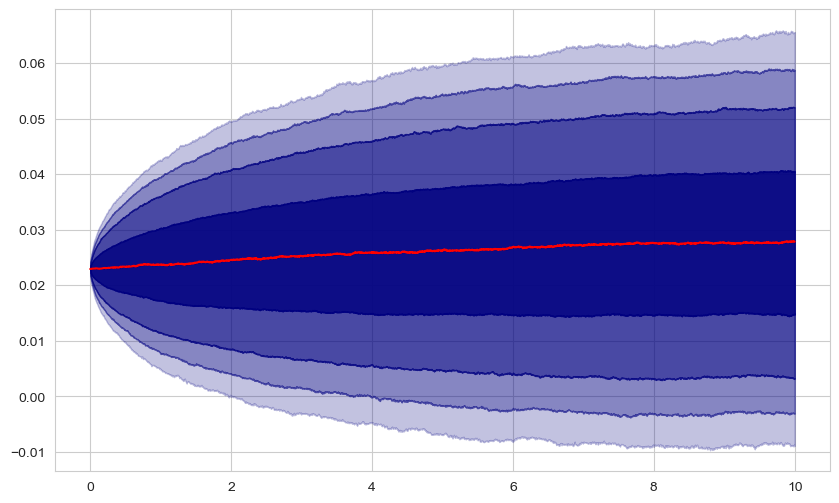

In [29]:
percentiles = np.percentile(short_rates, [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
fan_chart(time_points, percentiles, ax=ax, color="navy")
plt.show()

## Export the simulated short rates

In [22]:
short_rates = pd.DataFrame(short_rates)
#short_rates.to_excel(os.path.join(output_folder, "short_rates_sim.xlsx"))

## Define functions for calculating zero coupon bond prices

In [30]:
def calculate_zero_coupon_yield(time_to_maturity: Union[float, np.ndarray],
                                initial_short_rate: float,
                                kappa: float,
                                theta: float,
                                beta: float,
                                risk_premium: float):
    y_infty = theta - risk_premium * beta / kappa - beta ** 2 / (2 * kappa ** 2)

    b = 1 / kappa * (1 - np.exp(-kappa * time_to_maturity))
    a = y_infty * (time_to_maturity - b) + beta ** 2 / (4 * kappa) * b ** 2

    return (a + b * initial_short_rate) / time_to_maturity

def calculate_zero_coupon_price(time_to_maturity: Union[float, np.ndarray],
                                initial_short_rate: float,
                                kappa: float,
                                theta: float,
                                beta: float,
                                risk_premium: float):

    y_infty = theta - risk_premium * beta / kappa - beta**2 / (2 * kappa**2)

    b = 1 / kappa * (1 - np.exp(-kappa * time_to_maturity))
    a = y_infty * (time_to_maturity  - b) + beta**2 / (4 * kappa) * b**2

    return np.exp(- a - b * initial_short_rate)

### Conver yields for a specific year to a DataFrame for inspection

In [25]:
year_to_inspect = 10
df_year5 = pd.DataFrame(zcb_yields[year_to_inspect])
print(f"Zero-coupon yields for year {year_to_inspect}:\n", df_year5.head())


Zero-coupon yields for year 10:
        1       2       3       4       5       6       7       8       9   \
0 0.03459 0.03518 0.03570 0.03615 0.03655 0.03690 0.03722 0.03750 0.03775   
1 0.01408 0.01603 0.01778 0.01937 0.02080 0.02210 0.02328 0.02436 0.02534   
2 0.02025 0.02179 0.02317 0.02441 0.02553 0.02655 0.02747 0.02831 0.02907   
3 0.06448 0.06309 0.06180 0.06061 0.05950 0.05848 0.05753 0.05665 0.05584   
4 0.02508 0.02630 0.02739 0.02837 0.02925 0.03004 0.03076 0.03141 0.03200   

       10      11      12      13      14      15      16      17      18  \
0 0.03798 0.03819 0.03837 0.03854 0.03870 0.03884 0.03897 0.03909 0.03920   
1 0.02624 0.02706 0.02782 0.02851 0.02915 0.02974 0.03029 0.03079 0.03126   
2 0.02977 0.03041 0.03099 0.03153 0.03202 0.03248 0.03290 0.03329 0.03365   
3 0.05509 0.05440 0.05376 0.05316 0.05261 0.05209 0.05162 0.05117 0.05076   
4 0.03254 0.03303 0.03348 0.03389 0.03427 0.03462 0.03494 0.03524 0.03552   

       19      20  
0 0.03930 0.03939  
1

## Simulate ZCB yields and prices for maturities 10y and 10y - delta t

In [33]:
#Yields
zcb_yield_10y_mv = np.zeros((num_sim, num_time_steps + 1))
zcb_yield_10y_minus_delta_t = np.zeros((num_sim, num_time_steps + 1))

for i, t in enumerate(time_points):
    zcb_yield_10y_mv[:, i] = calculate_zero_coupon_yield(10.0, short_rates[:, i], kappa, theta, beta, rp)
    zcb_yield_10y_minus_delta_t[:, i] = calculate_zero_coupon_yield(10.0 - dt, short_rates[:, i], kappa, theta, beta, rp)

In [45]:
#Prices
zcb_10y_mv = np.zeros((num_sim, num_time_steps + 1))
zcb_10y_minus_delta_t = np.zeros((num_sim, num_time_steps + 1))

for i, t in enumerate(time_points):
    zcb_10y_mv[:, i] = calculate_zero_coupon_price(10.0, short_rates[:, i], kappa, theta, beta, rp)
    zcb_10y_minus_delta_t[:, i] = calculate_zero_coupon_price(10.0 - dt, short_rates[:, i], kappa, theta, beta, rp)

In [38]:
def yearly_price(file, ppa, header=True):
    if header==True:
        yearly_columns = file.iloc[1:, ::ppa]

    else:
        yearly_columns = file.iloc[:, ::ppa]

    return yearly_columns

In [48]:
zcb_10y_mv_yearly = zcb_10y_mv[:, ::252]

### Plot fan chart of zero coupon bond yields and prices

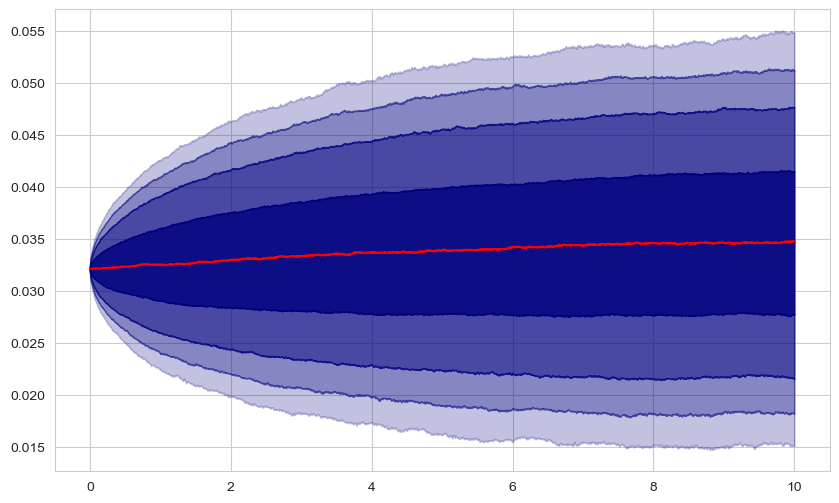

In [35]:
#Yields
percentiles = np.percentile(zcb_yield_10y_mv, [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
fan_chart(time_points, percentiles, ax=ax, color="navy")
plt.show()

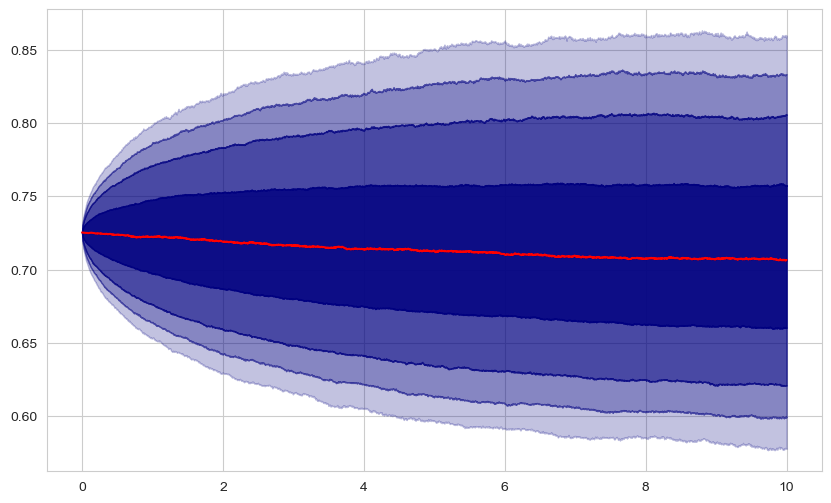

In [36]:
#Prices
percentiles = np.percentile(zcb_10y_mv, [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
fan_chart(time_points, percentiles, ax=ax, color="navy")
plt.show()

## Calculate bond returns

In [37]:
zcb_ret = zcb_10y_minus_delta_t[:, 1:] / zcb_10y_mv[:, :-1] - 1.0

In [50]:
zcb_yearly_ret = zcb_10y_mv_yearly[:, 1:] / zcb_10y_mv_yearly[:, :-1] - 1.0

## Calculate zero coupon bond yield for a give time and durations

In [56]:
def zcb_yield_at_time_for_duration(years: range, maturities: range, ppa: float, short_rates):
    """
    Function to calculate zero coupon bond yields at a given time for a range of maturities.

    Parameters:
        years: the range of years at which to calculate the yields. If you want to calculate 10 years into the future, the range is range(1, 11).

        maturities: the range of maturities for which to calculate the yields. If you want to calculate yields for maturities from 1 to 20 years, the range is range(1, 21).

        ppa: periods per annum.
    """

    # Dictionary to store computed yields; keys will be simulation year, and each value will be another dictionary with maturities as keys.
    zcb_yields = {}

    short_rates = pd.DataFrame(short_rates)

    # Loop over each simulation year
    for year in years:
        # Compute the index corresponding to the end of the year.
        index = year * ppa
        # Ensure the index does not exceed the simulation length
        if index >= short_rates.shape[1]:
            index = short_rates.shape[1] - 1

        # Extract the short rates at the selected time (for all simulation paths)
        sr_at_year = short_rates.iloc[:, index].values

        # Initialise a dictionary for this year's maturities
        zcb_yields[year] = {}

        # Loop over each maturity and compute the zero-coupon yield directly.
        for maturity in maturities:
            # Call the yield function directly
            yield_values = calculate_zero_coupon_yield(maturity, sr_at_year, kappa, theta, beta, rp)
            # Store the computed yields in the dictionary.
            zcb_yields[year][maturity] = yield_values

    return zcb_yields

In [57]:
ppa = ppa                   #Periods per annum
years = range(1, 11)        #Years 1 through 10
maturities = range(1, 21)   #Maturities from 1 to 20 years

zcb_yields = zcb_yield_at_time_for_duration(years, maturities, ppa, short_rates)

In [61]:
year_1 = pd.DataFrame(zcb_yields[1])

In [ ]:
# Option 2: Recompute prices from yields via the implied short rate.
zcb_prices_from_yield = {}

for year, yields_dict in zcb_yields.items():
    zcb_prices_from_yield[year] = {}
    for maturity, yield_array in yields_dict.items():
        # Calculate a and b for this maturity
        y_infty = theta - rp * beta / kappa - beta ** 2 / (2 * kappa ** 2)
        b = 1 / kappa * (1 - np.exp(-kappa * maturity))
        a = y_infty * (maturity - b) + beta ** 2 / (4 * kappa) * b ** 2

        # Invert the yield formula to get the implied short rate
        implied_sr = (yield_array * maturity - a) / b

        # Compute the price using the pricing function
        price_array = calculate_zero_coupon_price(maturity, implied_sr, kappa, theta, beta, rp)
        zcb_prices_from_yield[year][maturity] = price_array

# Example: inspect prices for year 5
df_prices_model_year5 = pd.DataFrame(zcb_prices_from_yield[5])
print("Zero-coupon bond prices (via model) for year 5:\n", df_prices_model_year5.head())